In [1]:
# Import libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv(r"C:\Users\tanay\Downloads\1_boston_housing.csv")


In [3]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
# Build DNN model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

C:\Users\tanay\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [8]:
model.fit(X_train, y_train, epochs=100, batch_size=16, validation_split=0.1)


Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - loss: 566.4145 - mae: 21.9412 - val_loss: 519.4775 - val_mae: 21.2262
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 481.2372 - mae: 19.9286 - val_loss: 412.2798 - val_mae: 18.6522
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 349.0361 - mae: 16.5110 - val_loss: 256.7034 - val_mae: 14.1829
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 184.4841 - mae: 11.1338 - val_loss: 107.8982 - val_mae: 8.1637
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 81.0888 - mae: 6.7622 - val_loss: 50.6818 - val_mae: 4.5959
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 46.5224 - mae: 5.0941 - val_loss: 38.2877 - val_mae: 3.8581
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 32.1279 - mae: 4.2236 - val_loss: 35.5906 - val_mae: 3.7937
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 26.4222 - mae: 3.8419 - val_loss: 34.2479 - val_mae: 3.7964
Epoch 9/100
23/23 ━━━━━━━

In [9]:
# Evaluation
loss, mae = model.evaluate(X_test, y_test)
print("MSE:", loss)
print("MAE:", mae)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 11.7461 - mae: 2.3358
MSE: 11.746147155761719
MAE: 2.3357510566711426


In [10]:
# Predictions
predictions = model.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


In [11]:
# R2 Score
r2 = r2_score(y_test, predictions)
print("R2 Score:", r2)

R2 Score: 0.8398262377631909


In [12]:
# Sample output
for i in range(5):
    print(f"Actual: {y_test[i]} | Predicted: {predictions[i][0]}")

Actual: 23.6 | Predicted: 27.4487247467041
Actual: 32.4 | Predicted: 34.41286087036133
Actual: 13.6 | Predicted: 16.229534149169922
Actual: 22.8 | Predicted: 24.895896911621094
Actual: 16.1 | Predicted: 16.26660919189453


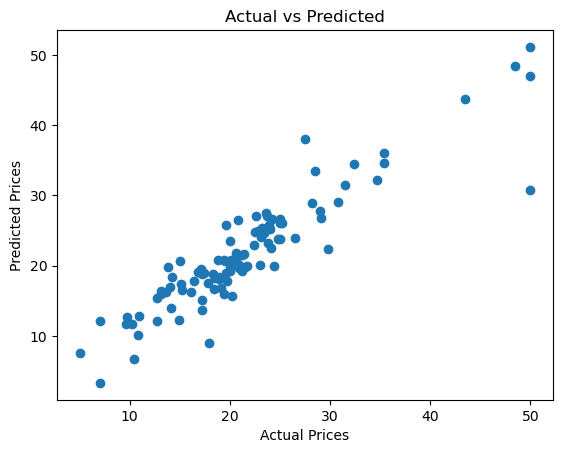

In [13]:
# Graph
plt.scatter(y_test, predictions)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")
plt.show()
